# IMPORTACIÓN DE LIBRERÍAS

In [15]:

import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, classification_report

# CARGA Y PREPROCESAMIENTO DE DATOS

In [16]:
# Cargar el dataset
df = pd.read_csv("test.csv")
df

# Creacion para una nueva Clasificacion

In [17]:
# 1. Crear una nueva columna para la clasificación multiclase
df['satisfaction_multiclass'] = df['satisfaction'].copy()

# 2. Definir condiciones para clasificación mejorada
# Retraso significativo en llegada (>30 minutos)
high_delay = df['Arrival Delay in Minutes'] > 30
# Mal servicio (puntuación <= 2 en servicios clave)
poor_service = (
    (df['Inflight wifi service'] <= 2) |
    (df['Food and drink'] <= 2) |
    (df['Seat comfort'] <= 2) |
    (df['Inflight entertainment'] <= 2) |
    (df['Cleanliness'] <= 2)
)

# 3. Aplicar la nueva clasificación
# Si originalmente era "neutral or dissatisfied" Y (tiene retraso alto O mal servicio)
df.loc[(df['satisfaction'] == 'neutral or dissatisfied') & (high_delay | poor_service), 
       'satisfaction_multiclass'] = 'dissatisfied'

# 4. Clasificar como "neutral" los que no cumplen condiciones de insatisfacción
df.loc[(df['satisfaction'] == 'neutral or dissatisfied') & 
       (~high_delay & ~poor_service), 
       'satisfaction_multiclass'] = 'neutral'

# 5. Verificar la distribución de las nuevas clases
print("Distribución de clases original:")
print(df['satisfaction'].value_counts())
print("\nDistribución de clases multiclase:")
print(df['satisfaction_multiclass'].value_counts())

Distribución de clases original:
satisfaction
neutral or dissatisfied    14573
satisfied                  11403
Name: count, dtype: int64

Distribución de clases multiclase:
satisfaction_multiclass
dissatisfied    11637
satisfied       11403
neutral          2936
Name: count, dtype: int64


# Preprocesamiento

In [18]:
# 6. Manejo de datos faltantes
print('\nDATOS VACIOS')
print(pd.isnull(df).sum())


DATOS VACIOS
Unnamed: 0                            0
id                                    0
Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             83
satisfaction              

In [19]:
# Reemplazar '?' con NaN y eliminar filas
data = df.copy()
data = data.replace('?', np.nan)
rows_before = len(data)
data = data.dropna()
rows_after = len(data)
print(f"  Filas eliminadas: {rows_before - rows_after}")
print(f"  Filas restantes: {rows_after}")

# 7. Eliminar columnas innecesarias
colum_i = ['Unnamed: 0', 'id','satisfaction']
data = data.drop(columns=colum_i, errors='ignore')


  Filas eliminadas: 83
  Filas restantes: 25893


In [20]:
# 8. Codificación de variables categóricas
# a) Gender - Binary Encoding
data['Gender'] = data['Gender'].map({'Female': 0, 'Male': 1})
# b) Customer Type - Binary Encoding
data['Customer Type'] = data['Customer Type'].map({'Loyal Customer': 1, 'disloyal Customer': 0})
# c) Type of Travel - Binary Encoding
data['Type of Travel'] = data['Type of Travel'].map({'Business travel': 1, 'Personal Travel': 0})
# d) Class - Ordinal Encoding
class_mapping = {'Eco': 0, 'Eco Plus': 1, 'Business': 2}
data['Class'] = data['Class'].map(class_mapping)
# e) satisfaction_multiclass - Label Encoding
le = LabelEncoder()
data['satisfaction_multiclass'] = le.fit_transform(data['satisfaction_multiclass'])
print("\nMapping para satisfaction_multiclass:")
for i, class_name in enumerate(le.classes_):
    print(f"  {class_name}: {i}")



Mapping para satisfaction_multiclass:
  dissatisfied: 0
  neutral: 1
  satisfied: 2


In [21]:
# 9. Normalización de características
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Seleccion de "X" y "y"

In [30]:
# Separar características y etiquetas
X = data.drop('satisfaction_multiclass', axis=1).values
y = data['satisfaction_multiclass'].values

# Normalizar características
X_norm, mu, sigma = featureNormalize(X)

# 10. División de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.2, stratify=y, random_state=42
)

print(f"\nTotal de muestras: {len(X_norm)}")
print(f"Muestras de entrenamiento: {len(X_train)} ({len(X_train)/len(X_norm)*100:.1f}%)")
print(f"Muestras de prueba: {len(X_test)} ({len(X_test)/len(X_norm)*100:.1f}%)")



Total de muestras: 25893
Muestras de entrenamiento: 20714 (80.0%)
Muestras de prueba: 5179 (20.0%)


# PREPARACIÓN DE DATOS PARA PYTORCH

In [23]:
# Configurar dispositivo (GPU si está disponible)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsando dispositivo: {device}")

# Convertir datos a tensores de PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Crear DataLoaders
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)



Usando dispositivo: cuda


# DEFINICIÓN DE LA RED NEURONAL

In [24]:

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, num_classes):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(hidden_size2, num_classes)
    
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.dropout1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.dropout2(out)
        out = self.fc3(out)
        return out


In [25]:
# Hiperparámetros
input_size = X_train.shape[1]
hidden_size1 = 128
hidden_size2 = 64
num_classes = len(np.unique(y_train))
learning_rate = 0.001
num_epochs = 60

# Crear el modelo
model = MLP(input_size, hidden_size1, hidden_size2, num_classes).to(device)

# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Listas para almacenar métricas
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []


# ENTRENAMIENTO DEL MODELO

In [26]:
print("\nIniciando entrenamiento...")
for epoch in range(num_epochs):
    # Modo entrenamiento
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass y optimización
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Estadísticas
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    # Calcular métricas de entrenamiento
    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    
    # Modo evaluación
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    # Calcular métricas de prueba
    test_loss = test_loss / len(test_loader)
    test_accuracy = 100 * correct / total
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)
    
    # Imprimir progreso
    print(f'Época [{epoch+1}/{num_epochs}], '
          f'Pérdida Entrenamiento: {train_loss:.4f}, '
          f'Precisión Entrenamiento: {train_accuracy:.2f}%, '
          f'Pérdida Prueba: {test_loss:.4f}, '
          f'Precisión Prueba: {test_accuracy:.2f}%')



Iniciando entrenamiento...
Época [1/60], Pérdida Entrenamiento: 0.5182, Precisión Entrenamiento: 79.85%, Pérdida Prueba: 0.3452, Precisión Prueba: 87.02%
Época [2/60], Pérdida Entrenamiento: 0.3426, Precisión Entrenamiento: 86.58%, Pérdida Prueba: 0.2577, Precisión Prueba: 90.35%
Época [3/60], Pérdida Entrenamiento: 0.2824, Precisión Entrenamiento: 89.29%, Pérdida Prueba: 0.2199, Precisión Prueba: 91.54%
Época [4/60], Pérdida Entrenamiento: 0.2491, Precisión Entrenamiento: 90.36%, Pérdida Prueba: 0.1987, Precisión Prueba: 92.22%
Época [5/60], Pérdida Entrenamiento: 0.2298, Precisión Entrenamiento: 90.96%, Pérdida Prueba: 0.1879, Precisión Prueba: 92.74%
Época [6/60], Pérdida Entrenamiento: 0.2099, Precisión Entrenamiento: 91.76%, Pérdida Prueba: 0.1741, Precisión Prueba: 93.16%
Época [7/60], Pérdida Entrenamiento: 0.2028, Precisión Entrenamiento: 91.98%, Pérdida Prueba: 0.1779, Precisión Prueba: 92.86%
Época [8/60], Pérdida Entrenamiento: 0.1915, Precisión Entrenamiento: 92.49%, Pérdi

# VISUALIZACIÓN DE RESULTADOS

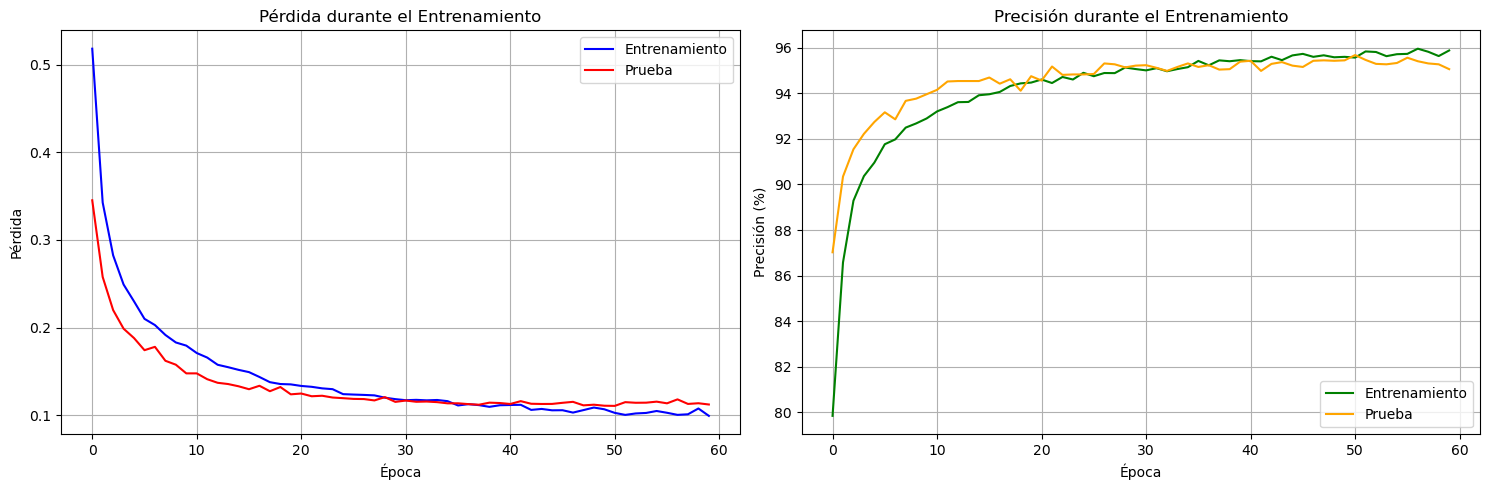

In [27]:
plt.figure(figsize=(15, 5))

# Gráfica de pérdida
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Entrenamiento', color='blue')
plt.plot(test_losses, label='Prueba', color='red')
plt.title('Pérdida durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# Gráfica de precisión
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Entrenamiento', color='green')
plt.plot(test_accuracies, label='Prueba', color='orange')
plt.title('Precisión durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Precisión (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# EVALUACIÓN FINAL DEL MODELO

In [28]:
print("\nEvaluación final del modelo:")
model.eval()
y_pred = []
y_true = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        y_pred.extend(predicted.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

# Calcular métricas finales
accuracy = accuracy_score(y_true, y_pred)
print(f"\nPrecisión final en el conjunto de prueba: {accuracy * 100:.2f}%")

# Reporte de clasificación detallado
print("\nReporte de clasificación:")
print(classification_report(
    y_true, 
    y_pred, 
    target_names=le.classes_,
    digits=4
))




Evaluación final del modelo:

Precisión final en el conjunto de prueba: 95.06%

Reporte de clasificación:
              precision    recall  f1-score   support

dissatisfied     0.9519    0.9897    0.9704      2321
     neutral     0.8724    0.9231    0.8970       585
   satisfied     0.9716    0.9177    0.9439      2273

    accuracy                         0.9506      5179
   macro avg     0.9320    0.9435    0.9371      5179
weighted avg     0.9516    0.9506    0.9505      5179



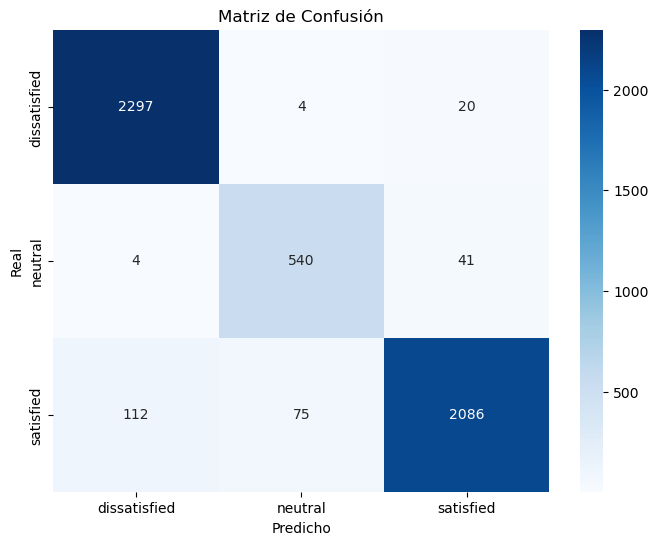

In [29]:
# Matriz de confusión
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, 
            yticklabels=le.classes_)
plt.title('Matriz de Confusión')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()